# Project 1:
# Simulation and estimation in a Markov model of breast cancer

## Part 1

States (columns in P matrix):   
1: Undergone surgery (healthy)   
2: Local reoccurence (cancer)   
3: Distant metastatis (cancer)   
4: Both cancers (cancer)   
5: Death (death)

In [1]:
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

### Task 1

Assume that one time step equals one month. Simulate 1000 women, all starting in state 1, until death.   
Summarize the lifetime distribution of the women, after surgery, for example using a histogram.   
In what proportion of women does the cancer eventually reappear, locally?

In [2]:
### Probability matrix
P = np.array([
    [0.9915, 0.005, 0.0025, 0,     0.001],
    [0,      0.986, 0.005,  0.004, 0.005],
    [0,      0,     0.992,  0.003, 0.005],
    [0,      0,     0,      0.991, 0.009],
    [0,      0,     0,      0,     1    ]
])
print(P[0,:])

### Possible states (0-indexed)
S = np.array([0,1,2,3,4])
print(S)

[0.9915 0.005  0.0025 0.     0.001 ]
[0 1 2 3 4]


In [3]:
#Random seed
np.random.seed(43)
#Number of observations wanted (per sample)
N_obs = 1000
#Initialise states as 0 (healthy)
states = np.zeros(N_obs, dtype=int)

#Initialise lifetimes
lifetimes = np.zeros(N_obs, dtype=int)

#Initialise list for logging states history (to be converted into a matrix)
hist = [states.copy()]

### Time loop
#While there are still women alive
while not np.all(states == 4):

    ### Loop for each woman
    for i in range(N_obs):
        #Extract state
        state = states[i] 

        #Only proceed if not dead
        if state != 4:
            #Extract transistion probability
            prob_trans = P[state,:]

            #Determine transition stochastically
            new_state = np.random.choice(a=S, p=prob_trans)

            #Update state and lifetime
            states[i] = new_state
            lifetimes[i] += 1

    #Log state in history list
    hist.append(states.copy())  

#Convert history into matrix with rows denoting time step, and cols denoting each woman
hist = np.array(hist)

In [4]:
### Post-processing
#Compute proportion of women for whom the cancer eventually reappear, locally
#(who has been in state 2)
loc_reocc = 0
for i in range(N_obs):
    woman_i = hist[:,i]
    if np.any(woman_i == 1):
        loc_reocc += 1
loc_reocc /= N_obs

mean_sample = np.mean(lifetimes)
var_sample = np.var(lifetimes, ddof=1)

In [5]:
###Check results
print("Shape of hist: ", np.shape(hist))
print("Shape of lifetimes: ", np.shape(lifetimes))
print(f"Proportion of local reoccurence:\n{loc_reocc:.4f}")

print("lifetimes of first 10 women:")
print(lifetimes[:10])
print(f"max: {np.max(lifetimes)},  min: {np.min(lifetimes)}")
print(f"mean: {mean_sample:.2f},  stddev: {math.sqrt(var_sample):.2f}")

Shape of hist:  (1358, 1000)
Shape of lifetimes:  (1000,)
Proportion of local reoccurence:
0.5870
lifetimes of first 10 women:
[256 446 388  83 480 249 219 190 382 141]
max: 1357,  min: 1
mean: 258.32,  stddev: 181.88


[-0.5  0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5]


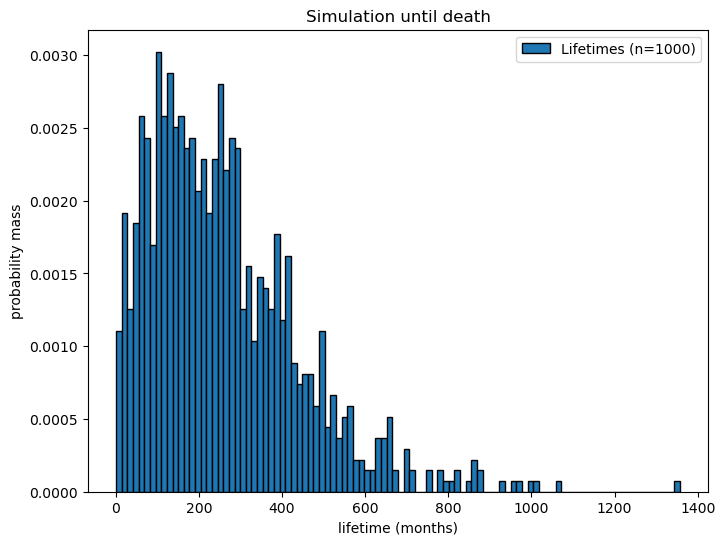

In [6]:
### Visualising
fig, ax = plt.subplots(figsize=(8,6))

#Edges for histogram with spacing 1
bin_max_val = 10 #last value for centred bin
n_bins = bin_max_val+1
edges = np.linspace(-0.5, bin_max_val+0.5, num=n_bins+1)
print(edges)

ax.hist(
    lifetimes, 
    bins=100,
    density=True,
    edgecolor='black',
    #alpha=0.9,
    label= f"Lifetimes (n={N_obs:.0f})"
)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability mass')
ax.set_title('Simulation until death')
ax.legend()

plt.show()

### Part 2

In your simulations, what is the distribution over the states at t = 120?   
Does this correspond to what we expect? Answer the question using an
appropriate statistical test.

In [7]:
### Compute expected state for t=120
t=120
#Initialise p_0:
# all women healthy -> all in state 0 -> state 0 has prob 1
p_0 = np.array([1, 0, 0, 0, 0])
#Compute P^t
P_exp_120 = np.linalg.matrix_power(P, t)
#Compute p_t
p_exp_120 = p_0 @ P_exp_120
print("Expected prob. at t=120 (p_120):\n", p_exp_120)
print("checking if sum is 1")
print(np.sum(p_exp_120))

Expected prob. at t=120 (p_120):
 [0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]
checking if sum is 1
1.0000000000000027


In [8]:
### Compute observed  state distribution at t=120

#Extract state at t=120
states_120 = hist[t,:]

#Initialise observed probability
obs_120 = np.zeros(5)

#Count occurences of possible states (0-4)
for i in range(5):
    obs_120[i] = np.sum(states_120==i)


print("Observed frequencies (obs_120):")
print(obs_120)
print("checking if sum is N_samples")
print(np.sum(obs_120))

Observed frequencies (obs_120):
[339. 172. 184.  65. 240.]
checking if sum is N_samples
1000.0


In [9]:
### Performing chi-squared test as GOF-test, to check how well distribution matches expected
#Compute expected counts
exp_120 = N_obs*p_exp_120
#Checking whether all exp values are above 5:
print("Expected values (ensure that all >5):")
print(exp_120) 
print("Observed values:")
print(obs_120)
### Computing test statistc 
#Number of bins (number of states)
n_bins_chi2 = 5

#Computing test statistic
chi2_test = 0
for i in range(n_bins_chi2):
    chi2_test += (obs_120[i]-exp_120[i])**2 / exp_120[i]

#Computing p_val
p_val = 1-sp.stats.chi2.cdf(x=chi2_test, df=n_bins_chi2-1)

print("Chi2 GOF-results:")
print(f"df: {n_bins_chi2-1}")
print(f"test statistic: {chi2_test:.4f}")
print(f"p-value: {p_val:.4f}")

Expected values (ensure that all >5):
[359.02626821 158.95603979 166.08689731  67.74149395 248.18930075]
Observed values:
[339. 172. 184.  65. 240.]
Chi2 GOF-results:
df: 4
test statistic: 4.5006
p-value: 0.3425


### Task 3

Does your simulated lifetimes follow a discrete phase-type distribution?

It has pmf

$$ P(T=t) = \boldsymbol{\pi(P_s)^t p_s} $$

and mean   

$$E(T) = \boldsymbol{\pi(I - P_s)^{-1}1}$$

In [10]:
### Computing expected discrete phase-type distribution
#pi: Dist. over states (0-3) at t=0
pi = np.array([1,0,0,0]) 

#P_s: Sub-matrix of P, removing last row and col
P_s = P[:-1,:-1]

#p_s: prob of dying from states (0-3)
# (the last column of P, minus its last row)
p_s = P[:-1, -1]

In [11]:
#Defining function for pmf and mean
def pmf_phase_type(t, pi=pi, P_s=P_s, p_s=p_s):
    return pi @ np.linalg.matrix_power(P_s,t) @ p_s

def mean_phase_type(pi=pi, P_s=P_s):
    d = np.shape(P_s)[0]
    mat_inv = np.linalg.inv(np.identity(d) - P_s)
    return pi @ mat_inv @ np.ones(d).T 

tgrid = np.arange(1400)
pmf_pt_vals = np.array([pmf_phase_type(t, pi=pi, P_s=P_s, p_s=p_s) for t in tgrid])

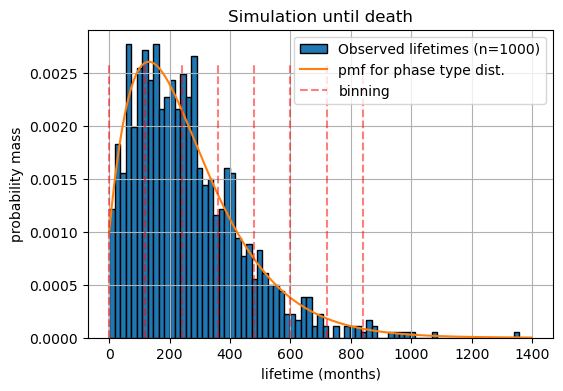

In [12]:
### Visualising with theoretical pmf

### Visualising
fig, ax = plt.subplots(figsize=(6,4))

#Edges to be used in second chi2 test
#Bin width of ten years
bin_width = 120
#8 ordinary bins
n_ord_bins = 7
edges2 = np.linspace(0, bin_width*n_ord_bins, n_ord_bins+1)

#Edges for histogram with spacing 1
#bin_max_val = 10 #last value for centred bin
##n_bins = bin_max_val+1
#edges = np.linspace(-0.5, bin_max_val+0.5, num=n_bins+1)
#print(edges)

ax.hist(
    lifetimes, 
    bins=75,
    density=True,
    edgecolor='black',
    #alpha=0.9,
    label= f"Observed lifetimes (n={N_obs:.0f})"
)

ax.plot(
    tgrid,
    pmf_pt_vals,
    label="pmf for phase type dist."
)

ax.vlines(edges2, 
          0, 
          max(pmf_pt_vals),
          label='binning',
          color='red',
          linestyles='--',
          alpha=0.5)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability mass')
ax.set_title('Simulation until death')
ax.legend()
ax.grid()

plt.show()

In [13]:
### Checking sample mean and theoretical mean:
mean_ana = mean_phase_type()

print(f"Sample mean: {mean_sample:.3f}")
print(f"Mean of phase type dist (true mean).: {mean_ana:.3f}")

Sample mean: 258.316
Mean of phase type dist (true mean).: 262.372


In [14]:
### Creating binning for chi2 test
print("bin edges (excl. infinity):")
print(edges2)

# Counting observations in 8 bins + 1 tail bin

def observed_counts(x, edges):
    # Extend last bin to infinity
    extended_edges = np.append(edges, np.inf)
    counts, _ = np.histogram(x, bins=extended_edges)
    return counts

obs2 = observed_counts(lifetimes, edges2)
print("Observed2:")
print(obs2)

def expected_counts(pmf, edges, n):
    expected = []
    
    # Regular bins
    for i in range(len(edges) - 1):
        
        a, b = edges[i], edges[i+1]
        prob = sum(pmf(k) for k in range(int(a), int(b)))
        expected.append(n * prob)
    
    # Last bin: from last edge to infinity
    a = edges[-1]
    prob_tail = 0
    k = int(a)
    
    # sum until probability is negligible
    while True:
        p = pmf(k)
        if p < 1e-12:   # stopping condition
            break
        prob_tail += p
        k += 1
    
    expected.append(n * prob_tail)
    
    return np.array(expected)

exp2 = expected_counts(pmf=pmf_phase_type, edges=edges2, n=N_obs)

print("Expected2:")
print(exp2)

print("checking whether both lists sum to N_samples")
print(np.sum(obs2))
print(np.sum(exp2))


bin edges (excl. infinity):
[  0. 120. 240. 360. 480. 600. 720. 840.]
Observed2:
[235 295 221 138  61  29   8  13]
Expected2:
[248.18930075 293.97284798 209.55302721 123.12380115  65.15085337
  32.26818474  15.26793079  12.47405388]
checking whether both lists sum to N_samples
1000
999.9999998723913


In [15]:
### Performing chi-squared test as GOF-test, to check how well distribution matches expected
#Compute expected counts
#Checking whether all exp values are above 5:
print("Expected values (ensure that all >5):")
print(exp2) 
print("Observed values:")
print(obs2)
### Computing test statistc 
#Number of bins (number of states)
n_bins_chi2 = len(exp2)
print("number of bins")
print(n_bins_chi2)

#Computing test statistic
chi2_test = 0
for i in range(n_bins_chi2):
    chi2_test += (obs2[i]-exp2[i])**2 / exp2[i]

#Computing p_val
p_val = 1-sp.stats.chi2.cdf(x=chi2_test, df=n_bins_chi2-1)

print("----Chi2 GOF-results:----")
print(f"df: {n_bins_chi2-1}")
print(f"test statistic: {chi2_test:.4f}")
print(f"p-value: {p_val:.4f}")

Expected values (ensure that all >5):
[248.18930075 293.97284798 209.55302721 123.12380115  65.15085337
  32.26818474  15.26793079  12.47405388]
Observed values:
[235 295 221 138  61  29   8  13]
number of bins
8
----Chi2 GOF-results:----
df: 7
test statistic: 7.2045
p-value: 0.4079


### Part 4

Estimate the expected lifetime, after surgery, of a woman who survives the
first 12 months following surgery, but whose breast cancer has also reappeared within the first 12 months, either locally or distant.

Hint: Use rejection sampling. Simulate a number of women, and discard
all simulations that do not meet the requirements. Do this until you have
reached 1000 acceptable simulations.

In [16]:
#Random seed
np.random.seed(43)
#Number of observations wanted
N_obs = 1000
#Initialise lifetimes
lifetimes = []
#Initialise variables tracking number of simulated women
women_all_count = 0
#Initialise state variable tracking how many women satisfies having reoccuring canser (state 1,2 or 3) 
#and being alive after first 12 months
survive_reocc_count = 0
#Initialise list for logging states history for women passing crit (for verifying simulation)
hist_pass = []
#Initialise list for logging states history for women failing crit (for verifying simulation)
hist_fail = []

print("Beginning simulation...")

### Loop for each woman - until lifetimes for women meeting criteria have been simulated
#while there are still women alive
while survive_reocc_count < N_obs:
    #Initialise state history for woman
    state = 0
    state_hist_i = [state]

    #Initialise lifetime = 0
    lifetime_i = 0

    #Initialise pass-criterium state (not passed by default)
    survive_reocc_i = False

    ### Time loop 
    #While women is not dead
    while state != 4:
        #Extract transistion probability
        prob_trans = P[state,:]

        #Determine transition stochastically
        new_state = np.random.choice(a=S, p=prob_trans)

        #Update lifetime and log new state in history
        lifetime_i += 1
        state_hist_i.append(new_state)

        #Update state
        state = state_hist_i[-1]

        #check if criterium is met at t=13: break if not
        if lifetime_i == 12:
            #Check whether women has had no state in [1,2,3]
            if any(x in [1,2,3] for x in state_hist_i):
                survive_reocc_i = True
            else:
                break

    #if criterium is met: increse counter, log the lifetime, and log the state history for woman in history list 
    if survive_reocc_i == True:
        survive_reocc_count += 1
        lifetimes.append(lifetime_i)
        hist_pass.append(state_hist_i) 
    else:
        hist_fail.append(state_hist_i)

    #Increase woman counter
    women_all_count += 1 

print("Simulation done!")

Beginning simulation...
Simulation done!


In [17]:
### Check results
mean_sample_t4 = np.mean(lifetimes)
print(f"Expected lifetime of women passing criterium:\n{mean_sample_t4:.2f} months\n {mean_sample_t4/12:.2f} years")

print("Length of lifetimes:", len(lifetimes))
print("Number of women failing criterium: ", len(hist_fail))
print(f"Number of women simulated: {women_all_count}")
print(f"Fraction of simulated women meeting criterium: {survive_reocc_count/women_all_count:.3f}")

print("Example of history of women passing crit")
print(hist_pass[0])
print("Example of history of women failing crit")
print(hist_fail[0])

Expected lifetime of women passing criterium:
174.16 months
 14.51 years
Length of lifetimes: 1000
Number of women failing criterium:  10684
Number of women simulated: 11684
Fraction of simulated women meeting criterium: 0.086
Example of history of women passing crit
[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4]
Example of history of women failing crit
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


[-0.5  0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5]


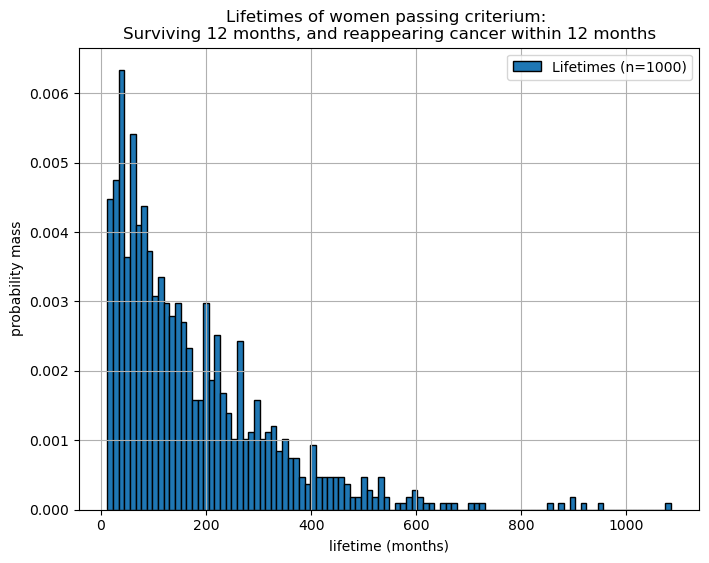

In [18]:
### Visualising
fig, ax = plt.subplots(figsize=(8,6))

#Edges for histogram with spacing 1
bin_max_val = 10 #last value for centred bin
n_bins = bin_max_val+1
edges = np.linspace(-0.5, bin_max_val+0.5, num=n_bins+1)
print(edges)

ax.hist(
    lifetimes, 
    bins=100,
    density=True,
    edgecolor='black',
    #alpha=0.9,
    label= f"Lifetimes (n={N_obs:.0f})"
)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability mass')
ax.set_title('Lifetimes of women passing criterium: \nSurviving 12 months, and reappearing cancer within 12 months')
ax.legend()
ax.grid()

plt.show()

### Task 5

What fraction of women die within the first 350 months? Answer this by
simulating 200 women, and record the fraction. Do this 100 times. Use con-
trol variates to reduce the variance.

How large a reduction in variance do you see, using control variates, as op-
posed to the crude Monte Carlo estimator?

Hint: Use the mean lifetime after surgery of the 200 simulations as the
control variate.

In [19]:
### Same simulation, but with using control variates (now women living longer than 350 months have to be simulated as well)
#Random seed
np.random.seed(43)
#Number of observations wanted (per sample)
N_obs = 200
#Number of samples wanted
N_samples = 100

#Initialise history of results
list_main_variable = []
#Initialise history for control varites
list_control_variates = []
#Initialise list for logging states history for women passing crit (for verifying simulation)
hist_pass = []
#Initialise list for logging states history for women failing crit (for verifying simulation)
hist_fail = []

print("Beginning simulation...")

### Loop for each woman - until lifetimes for women meeting criteria have been simulated
#while there are still women alive

for i in range(N_samples):

    #Initialise state variable tracking how many women satisfies criterium: 
    # dying within first 350 months
    crit_pass_count = 0

    #Initialise variables tracking number of simulated women
    women_all_count = 0

    #Initialise lifetimes 
    lifetimes = []
    
    #Create 1 sample of N_obs women
    while women_all_count < N_obs:
        #Initialise state history for woman
        state = 0
        state_hist_i = [state]

        #Initialise lifetime = 0
        lifetime_i = 0

        #Initialise pass-criterium state (not passed by default)
        crit_pass_i = True

        ### Time loop 
        #While women is not dead
        while state != 4:
            #Extract transistion probability
            prob_trans = P[state,:]

            #Determine transition stochastically
            new_state = np.random.choice(a=S, p=prob_trans)

            #Update lifetime and log new state in history
            lifetime_i += 1
            state_hist_i.append(new_state)

            #Update state
            state = state_hist_i[-1]

            #If women is not dead before t=350 and  crit is not (yet) failed: fail criterium
            if lifetime_i == 350 and crit_pass_i==True:
                crit_pass_i = False

        #Log lifetime 
        lifetimes.append(lifetime_i)
        
        #if criterium is met: increse counter, and log the state history for woman in history list 
        if crit_pass_i == True:
            crit_pass_count += 1
            hist_pass.append(state_hist_i) 
        else:
            hist_fail.append(state_hist_i)

        #Increase simulated woman counter
        women_all_count += 1 
    
    #Compute result
    frac_pass_t5 = crit_pass_count/women_all_count
    #Append result
    list_main_variable.append(frac_pass_t5)

    #Compute and append control variate (mean of lifetime)
    control_variate = np.mean(lifetimes)
    list_control_variates.append(control_variate)

    #Simulation Status
    if (i+1)%20 == 0:
        print(f"simulation {i+1} done")

#Convert to np.array
list_main_variable = np.array(list_main_variable)
list_control_variates = np.array(list_control_variates)

print("Simulation done!")

Beginning simulation...
simulation 20 done
simulation 40 done
simulation 60 done
simulation 80 done
simulation 100 done
Simulation done!


In [20]:
### Save/load resutls as/from npy file
np.save("Results_varred_mainvar_task5.npy",list_main_variable)
np.save("Results_varred_contrvar_task5.npy",list_control_variates)
#list_main_variable = np.load("Results_varred_mainvar_task5.npy", allow_pickle=True)
#list_control_variable = np.load("Results_varred_contrvar_task5.npy", allow_pickle=True)

In [21]:
#Check results
print("Crude MC: First 10 results:\n",list_main_variable[:10])
print("CV: First 10 results:\n",list_control_variates[:10])

print("\nSanity checks:")
print("Number of women failing criterium: ", len(hist_pass))
print("Number of women failing criterium: ", len(hist_fail))
print(f"Number of women simulated: {N_obs*N_samples}")

print("Example of history of women passing crit")
print(hist_pass[0])
print("Example of history of women failing crit")
print(hist_fail[0])

Crude MC: First 10 results:
 [0.725 0.7   0.74  0.75  0.75  0.68  0.76  0.76  0.755 0.735]
CV: First 10 results:
 [262.745 273.905 259.14  247.235 256.385 275.885 254.9   259.625 270.875
 260.445]

Sanity checks:
Number of women failing criterium:  14789
Number of women failing criterium:  5211
Number of women simulated: 20000
Example of history of women passing crit
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4]
Example of history of women failing crit
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [22]:
### Compute new variable with reduced variance

## Computing c
#Covariance of main and control raiable
cov_xz_mat = np.cov(list_main_variable, list_control_variates)
cov_xz = cov_xz_mat[0,1]
var_z = cov_xz_mat[1,1]
c = - cov_xz / var_z
print(f"cov_xz: {cov_xz:.2g}")
print(f"var_z: {var_z:.2g}")
print(f"c: {c:.2g}")

## Construct new variable, Y
#mean of lifetime (true mean)
mu_z = mean_phase_type()
print(f"mu_z (true): {mu_z:.2f}")
#New variable
Y = list_main_variable + c*(list_control_variates-mu_z)

cov_xz: -0.37
var_z: 1.9e+02
c: 0.0019
mu_z (true): 262.37


In [23]:
### Compare crude MC with Control Variate estmator

#Crude MC estimator
frac_MC_est = np.mean(list_main_variable)
frac_MC_var = np.var(list_main_variable, ddof=1)

#Control Variate estimator
frac_CV_est = np.mean(Y)
frac_CV_var = np.var(Y, ddof=1)

#Relative reduction in variance
var_rel_reduc = (frac_CV_var-frac_MC_var)/frac_MC_var

print(f"Crude MC estimator: {frac_MC_est:.3g}")
print(f"Crude MC variance: {frac_MC_var:.3g}")
print(f"Crude CV estimator: {frac_CV_est:.3g}")
print(f"Crude CV variance: {frac_CV_var:.3g}")
print(f"Relative reduction in variance: {var_rel_reduc*100:.2f} %")

Crude MC estimator: 0.739
Crude MC variance: 0.00113
Crude CV estimator: 0.738
Crude CV variance: 0.000426
Relative reduction in variance: -62.27 %


### Task 6

For the report, consider the following questions: What assumptions underlie
the discrete time Markov chain model? Are those assumptions realistic? How
may we relax some of these assumptions, possibly at the cost of increased
model complexity?

Assumptions:
1) Women can go from only having local cancer to only having distant metastatis (unrealistic)
2) The probabilities are time-stationary: having had cancer for a long time, doesn't change the prob of transitioning into death (any state only rely on previous state - common property of any Markov Chain)
3) Women cant go from any cancer state to a non-cancer state (cannot jump to state 1 from other states), as seen from 0-vals in first cols
